In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    dev = "cuda:0"
elif torch.backends.mps.is_available():
    dev = "mps"
else:
    dev = "cpu"
device = torch.device(dev)
device

device(type='mps')

In [3]:
device = torch.device("cpu")
device

device(type='cpu')

In [4]:
num_episodes = 100000
hidden_size = 128

In [5]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
    
        self.mean = nn.Linear(hidden_size, output_size)

        # self.log_std = nn.Linear(hidden_size, output_size)
        self.log_std = nn.Parameter(torch.zeros(output_size))  # global log std (learned, state-independent)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        mean = self.mean(x)

        # log_std = self.log_std(x)
        log_std = self.log_std

        # log_std = torch.clamp(log_std, -20, 2)
        std = torch.exp(log_std)

        return mean, std

In [6]:
class REINFORCEAgent:
    def __init__(self, obs_size, n_actions, hidden_size=64, lr=1e-3, gamma=0.99):
        self.policy = PolicyNetwork(obs_size, hidden_size, n_actions)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = gamma
        self.log_probs = []
        self.rewards = []

    def select_action(self, state, inference=False):
        state = torch.tensor(state, dtype=torch.float32)
        mean, std = self.policy(state)
        dist = Normal(mean, std)
        if inference:
            action = mean
        else:
            action = dist.sample()

        # action = torch.clamp(action, -2.0, 2.0)
        # action = torch.tanh(action) * 2.0  # scale to [-2, 2]

        self.log_probs.append(dist.log_prob(action).sum())
        return action.detach().numpy()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def update(self):
        returns = []
        R = 0
        for r in reversed(self.rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -torch.sum(torch.stack(self.log_probs) * returns)

        self.optimizer.zero_grad()
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()

        self.log_probs = []
        self.rewards = []

In [7]:
env = gym.make("Pendulum-v1")

obs_size = env.observation_space.shape[0]
n_actions = env.action_space.shape[0]

agent = REINFORCEAgent(obs_size, n_actions)

episode_rewards = []

best_avg_reward = -float('inf')  # track best moving average
window = 20  # moving average window

for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.store_reward(reward)
        total_reward += reward

    agent.update()

    if episode % 50 == 0:
        print(f"Episode {episode}, reward: {total_reward}")

    episode_rewards.append(total_reward)

    # Compute moving average
    if len(episode_rewards) >= window:
        moving_avg = np.mean(episode_rewards[-window:])
        # Save best network based on moving average
        if moving_avg > best_avg_reward:
            best_avg_reward = moving_avg
            torch.save(agent.policy.state_dict(), "best_pg.pth")

    print(f"Episode {episode} | Reward: {total_reward} | Moving Avg: {moving_avg if len(episode_rewards) >= window else total_reward:.2f}")

env.close()

Episode 0, reward: -1636.3705051898678
Episode 0 | Reward: -1636.3705051898678 | Moving Avg: -1636.37
Episode 1 | Reward: -1222.6811860323621 | Moving Avg: -1222.68
Episode 2 | Reward: -1212.134250126448 | Moving Avg: -1212.13
Episode 3 | Reward: -1371.0731467477742 | Moving Avg: -1371.07
Episode 4 | Reward: -1806.7666514779128 | Moving Avg: -1806.77
Episode 5 | Reward: -1729.8850534330109 | Moving Avg: -1729.89
Episode 6 | Reward: -1367.9746256356282 | Moving Avg: -1367.97
Episode 7 | Reward: -1687.7562599973164 | Moving Avg: -1687.76
Episode 8 | Reward: -1444.7695920224594 | Moving Avg: -1444.77
Episode 9 | Reward: -1771.0462689316166 | Moving Avg: -1771.05
Episode 10 | Reward: -1269.3768472820495 | Moving Avg: -1269.38
Episode 11 | Reward: -1800.6366130421961 | Moving Avg: -1800.64
Episode 12 | Reward: -1860.7077362060138 | Moving Avg: -1860.71
Episode 13 | Reward: -1512.9722813523476 | Moving Avg: -1512.97
Episode 14 | Reward: -1581.1063811952665 | Moving Avg: -1581.11
Episode 15 |

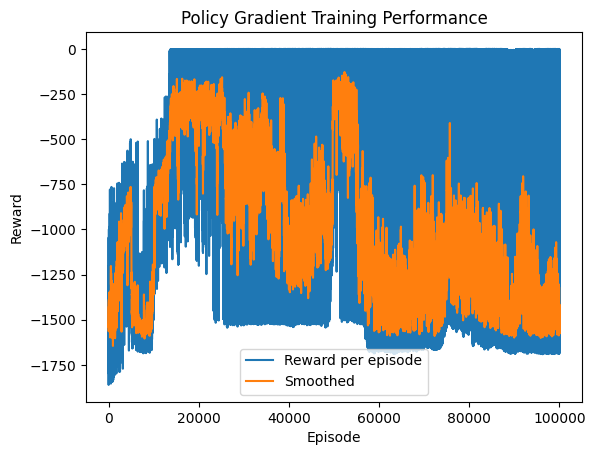

In [8]:
plt.plot(episode_rewards, label="Reward per episode")

# Optional smoothing
window = 20
smoothed = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)
plt.plot(range(window-1, len(episode_rewards)), smoothed, label="Smoothed")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Policy Gradient Training Performance")
plt.legend()
plt.show()

In [9]:
agent.policy.load_state_dict(torch.load("best_pg.pth"))

<All keys matched successfully>

In [10]:
test_env = gym.make("Pendulum-v1")

num_eval_episodes = 100
episode_rewards = []

for episode in range(num_eval_episodes):
    state, _ = test_env.reset()
    done = False
    total_reward = 0.0

    while not done:
        action = agent.select_action(state, inference=True)
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated

        total_reward += reward

    episode_rewards.append(total_reward)

test_env.close()

average_reward = sum(episode_rewards) / num_eval_episodes
print(f"Average reward over {num_eval_episodes} episodes: {average_reward:.2f}")

Average reward over 100 episodes: -265.30
